Статистика длительности сделок (в днях):
count    2167.000000
mean       50.783110
std       102.022534
min         0.000000
25%         6.000000
50%        19.000000
75%        47.500000
max      1278.000000
Name: Trade Duration, dtype: float64


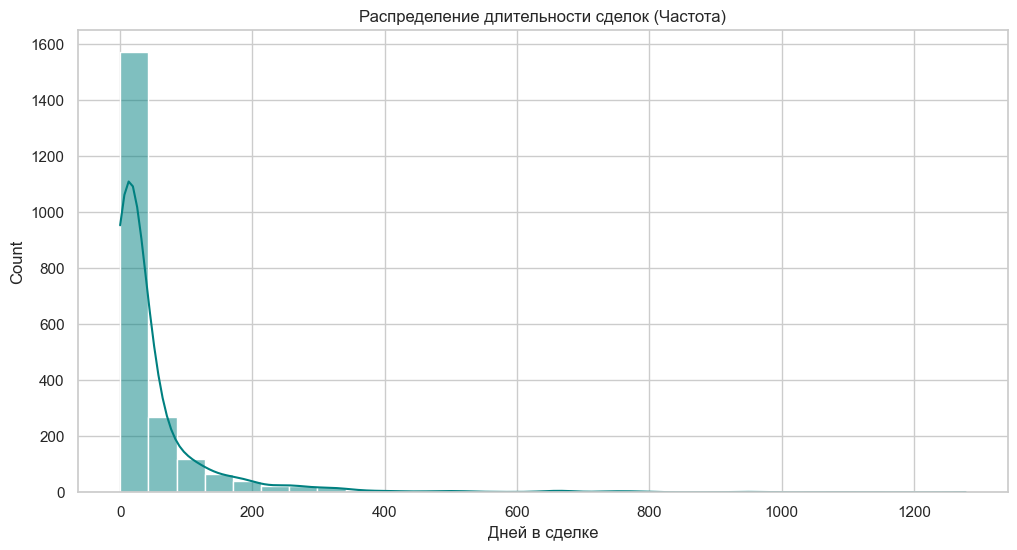

C:\Users\USER\AppData\Local\Temp\ipykernel_12580\916459040.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Profit %', y='Sector', palette='Set3')


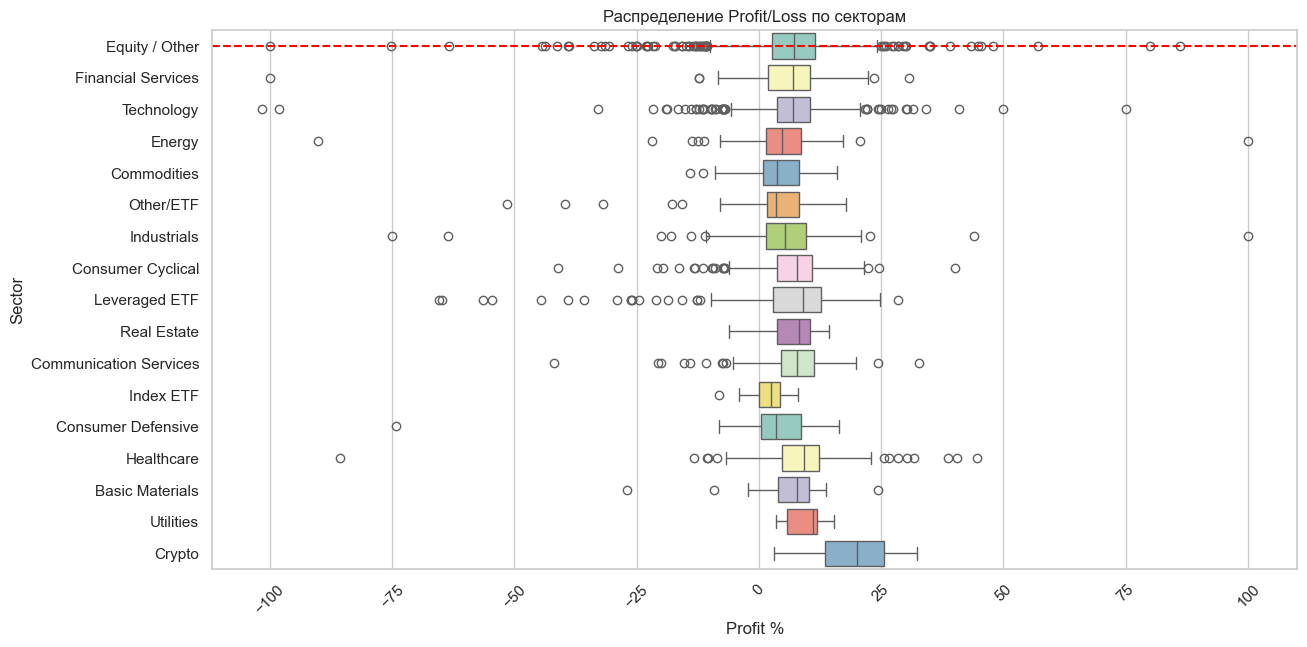

C:\Users\USER\AppData\Local\Temp\ipykernel_12580\916459040.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Trade Duration', y='Sector', palette='Pastel1')


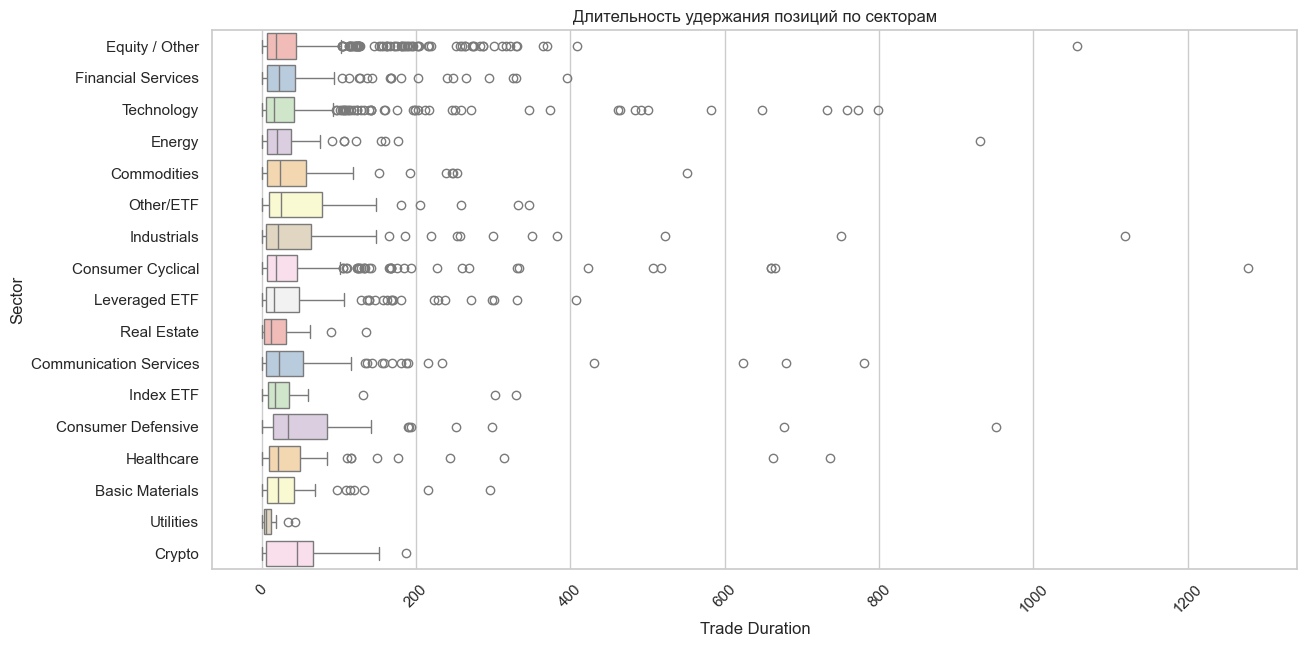


Сравнительная таблица Long vs Short:
            Profit %                   Trade Duration              Symbol
                mean median        std           mean median Total Trades
Long/Short                                                               
Long        6.804662  8.015  13.587684      40.600261   16.0         1532
Short       4.378337  5.380   9.546392      75.295597   28.0          636


C:\Users\USER\AppData\Local\Temp\ipykernel_12580\916459040.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Long/Short', y='Profit %', ax=axes[0], estimator='mean', palette='coolwarm')
C:\Users\USER\AppData\Local\Temp\ipykernel_12580\916459040.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Long/Short', y='Trade Duration', ax=axes[1], estimator='mean', palette='viridis')


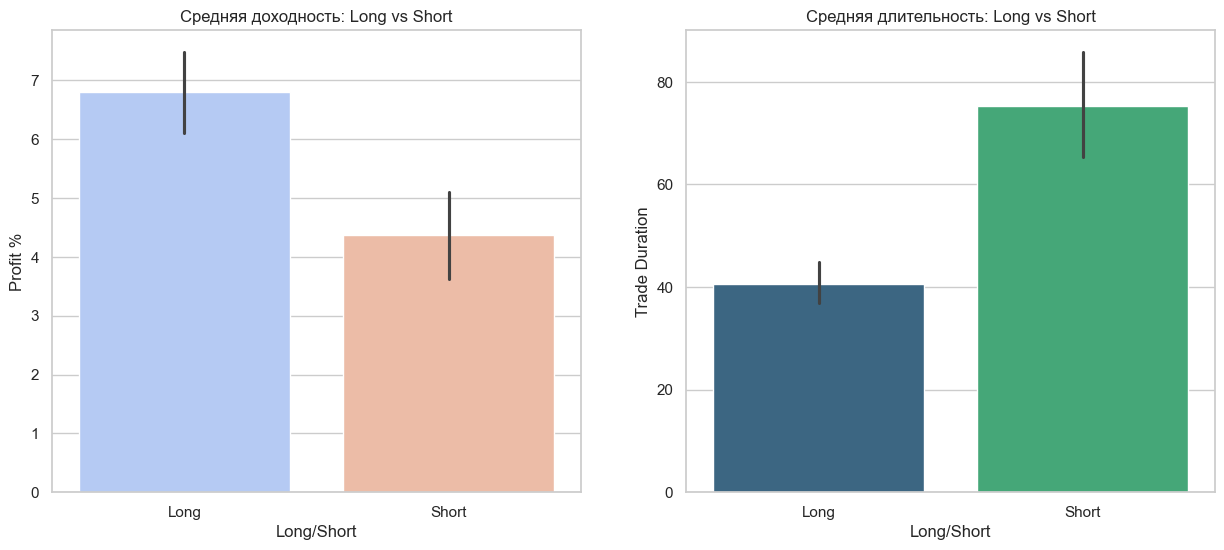

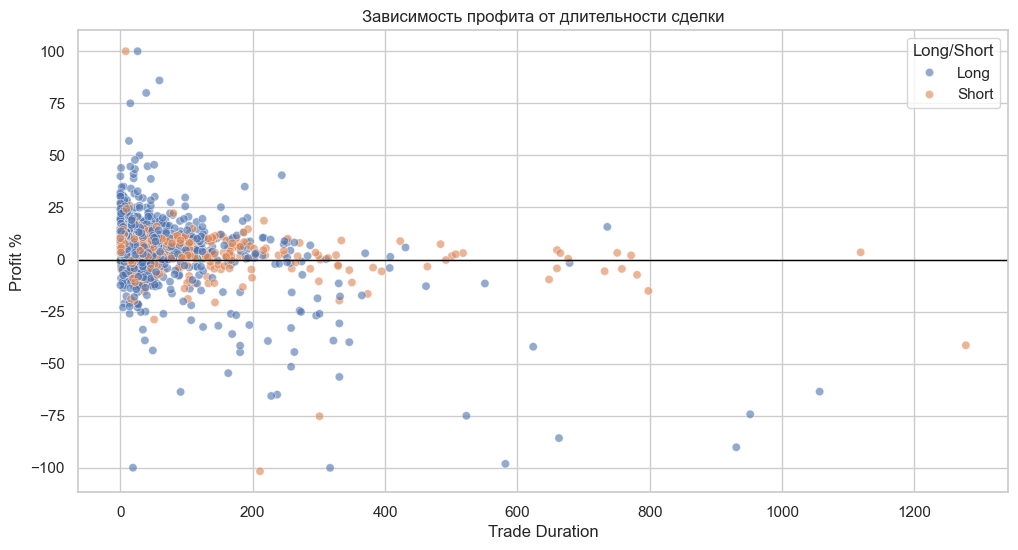

C:\Users\USER\AppData\Local\Temp\ipykernel_12580\916459040.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivot_day.index, y=pivot_day.values, ax=axes[1], order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='muted')


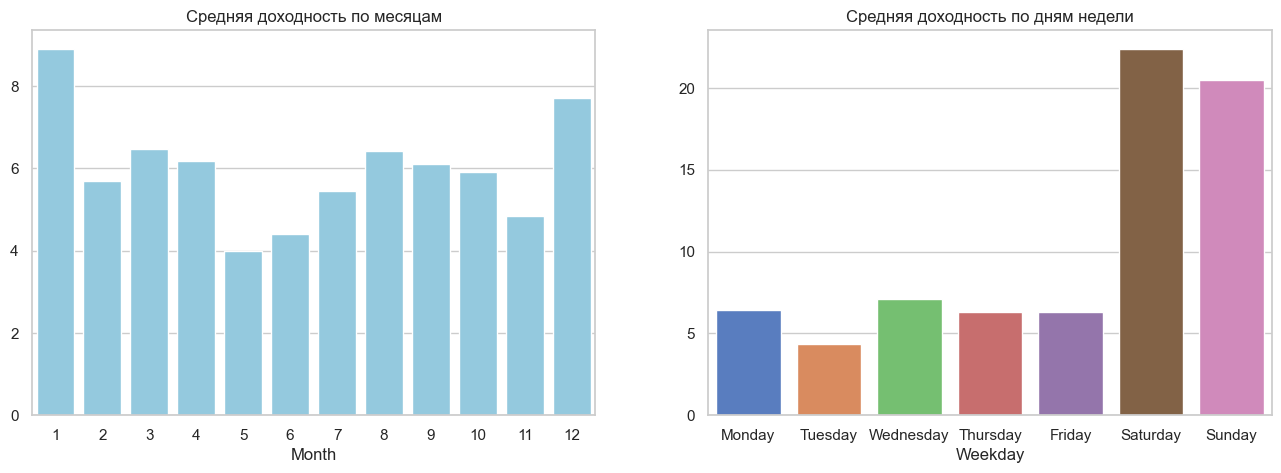

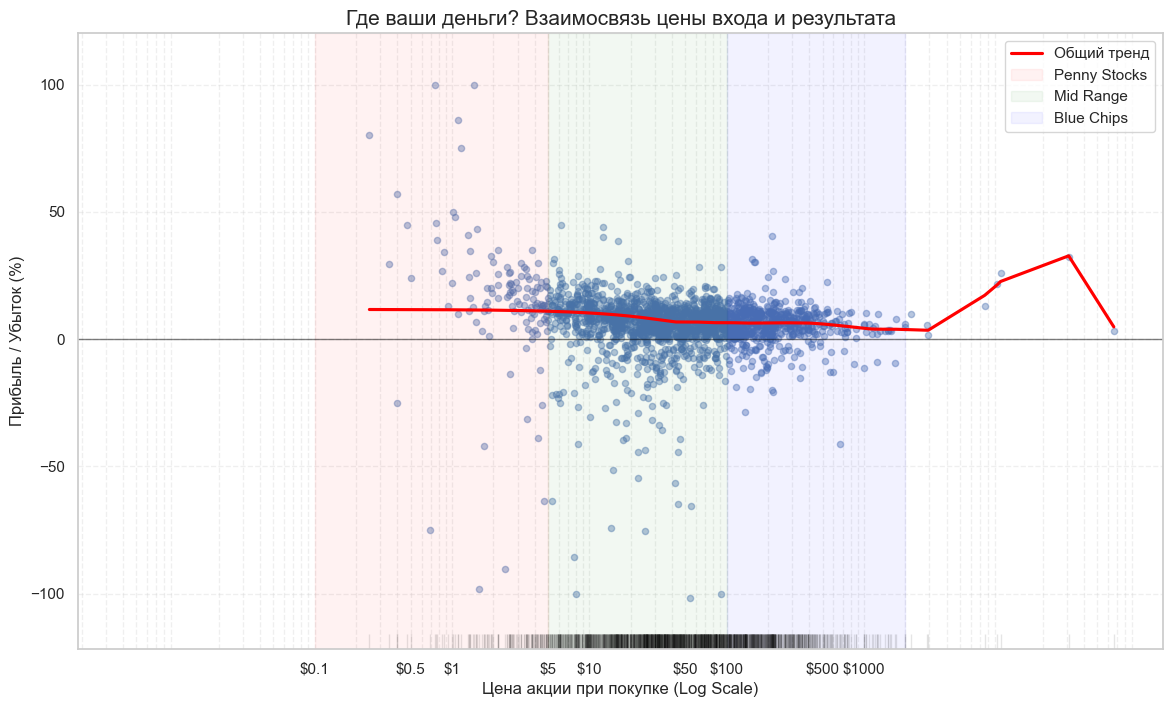

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем наш структурированный файл
df = pd.read_csv(r'C:\Users\USER\Desktop\Folder\Murat\DS\Outpeer\Capstone\NewTry\trades_structured2.csv')
df['Entry Date'] = pd.to_datetime(df['Entry Date'])

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- 1. АНАЛИЗ ДЛИТЕЛЬНОСТИ (DURATIONS) ---

# Статистика длительности
duration_stats = df['Trade Duration'].describe(percentiles=[.25, .5, .75])
print("Статистика длительности сделок (в днях):")
print(duration_stats)

# Гистограмма длительности
plt.figure()
sns.histplot(df['Trade Duration'], bins=30, kde=True, color='teal')
plt.title('Распределение длительности сделок (Частота)')
plt.xlabel('Дней в сделке')
plt.show()

# --- 2. СЕКТОРНЫЙ АНАЛИЗ (BOXPLOTS) ---

# Профит по секторам
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Profit %', y='Sector', palette='Set3')
plt.xticks(rotation=45)
plt.title('Распределение Profit/Loss по секторам')
plt.axhline(0, color='red', linestyle='--') # Линия безубыточности
plt.show()

# Длительность по секторам
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Trade Duration', y='Sector', palette='Pastel1')
plt.xticks(rotation=45)
plt.title('Длительность удержания позиций по секторам')
plt.show()

# --- 3. LONG/SHORT АНАЛИЗ ---

# Таблица Long/Short
ls_table = df.groupby('Long/Short').agg({
    'Profit %': ['mean', 'median', 'std'],
    'Trade Duration': ['mean', 'median'],
    'Symbol': 'count'
}).rename(columns={'count': 'Total Trades'})
print("\nСравнительная таблица Long vs Short:")
print(ls_table)

# Визуализация Long/Short (Доходность и Длительность)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=df, x='Long/Short', y='Profit %', ax=axes[0], estimator='mean', palette='coolwarm')
axes[0].set_title('Средняя доходность: Long vs Short')
sns.barplot(data=df, x='Long/Short', y='Trade Duration', ax=axes[1], estimator='mean', palette='viridis')
axes[1].set_title('Средняя длительность: Long vs Short')
plt.show()

# --- 4. ЗАВИСИМОСТЬ ПРОФИТА ОТ ВРЕМЕНИ ---

# Scatter plot: Профит vs Длительность
plt.figure()
sns.scatterplot(data=df, x='Trade Duration', y='Profit %', hue='Long/Short', alpha=0.6)
plt.axhline(0, color='black', lw=1)
plt.title('Зависимость профита от длительности сделки')
plt.show()

# --- 5. СЕЗОННОСТЬ (МЕСЯЦЫ И ДНИ) ---

# Тепловая карта: Доходность по месяцам и дням недели
pivot_month = df.groupby('Month')['Profit %'].mean()
pivot_day = df.groupby('Weekday')['Profit %'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=pivot_month.index, y=pivot_month.values, ax=axes[0], color='skyblue')
axes[0].set_title('Средняя доходность по месяцам')
sns.barplot(x=pivot_day.index, y=pivot_day.values, ax=axes[1], order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='muted')
axes[1].set_title('Средняя доходность по дням недели')
plt.show()

import numpy as np

# --- УЛУЧШЕННЫЙ АНАЛИЗ: ДОХОДНОСТЬ VS ЦЕНА АКЦИИ ---

plt.figure(figsize=(14, 8))

# 1. Используем прозрачность (alpha) и размер точек в зависимости от профита
# 2. Добавляем линию регрессии (Trendline), чтобы увидеть общую тенденцию
sns.regplot(data=df, x='Average Entry Price', y='Profit %', 
            scatter_kws={'alpha':0.4, 's':20}, 
            line_kws={'color':'red', 'label':'Общий тренд'}, 
            lowess=True) # Lowess покажет гибкий тренд, а не просто прямую

# 3. Логарифмическая шкала для X
plt.xscale('log')

# 4. Добавляем "ковровую" диаграмму (Rug plot) по краям, чтобы видеть плотность сделок
sns.rugplot(data=df, x='Average Entry Price', color="black", alpha=0.1)

# Настройка осей и меток
ticks = [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
plt.xticks(ticks, [f'${t}' for t in ticks])
plt.axhline(0, color='black', lw=1, alpha=0.5)

# 5. Разбиваем график на зоны (Penny, Mid, High Cap) для наглядности
plt.axvspan(0.1, 5, color='red', alpha=0.05, label='Penny Stocks')
plt.axvspan(5, 100, color='green', alpha=0.05, label='Mid Range')
plt.axvspan(100, 2000, color='blue', alpha=0.05, label='Blue Chips')

plt.title('Взаимосвязь цены входа и результата', fontsize=15)
plt.xlabel('Цена акции при покупке (Log Scale)', fontsize=12)
plt.ylabel('Прибыль / Убыток (%)', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()

In [10]:
# import pandas as pd

# Загружаем данные
# df = pd.read_csv('trades_structured.csv')

# 1. Приведение дат к формату datetime
df['Entry Date'] = pd.to_datetime(df['Entry Date'])
df['Exit Date'] = pd.to_datetime(df['Exit Date'])

# 2. Исправление Long/Short
df['Long/Short'] = df['Long/Short'].astype(str).str.strip().str.capitalize()

# 3. Исправление инверсии дат (если выход раньше входа)
mask_inv = df['Exit Date'] < df['Entry Date']
df.loc[mask_inv, ['Entry Date', 'Exit Date']] = df.loc[mask_inv, ['Exit Date', 'Entry Date']].values

# 4. Сдвиг выходных на понедельник (кроме Крипты)
def shift_weekend(row):
    dt = row['Entry Date']
    # 5 - Суббота, 6 - Воскресенье
    if row['Sector'] != 'Crypto' and dt.weekday() in [5, 6]:
        days_to_add = 7 - dt.weekday()
        return dt + pd.Timedelta(days=days_to_add)
    return dt

df['Entry Date'] = df.apply(shift_weekend, axis=1)

# 5. Обновление временных колонок после исправлений
df['Trade Duration'] = (df['Exit Date'] - df['Entry Date']).dt.days
df['Weekday'] = df['Entry Date'].dt.day_name()
df['Month'] = df['Entry Date'].dt.month
df['Year'] = df['Entry Date'].dt.year

# Убираем возможные отрицательные значения длительности после сдвига 
# (если вход сдвинулся на понедельник, а выход был в субботу/воскресенье)
df.loc[df['Trade Duration'] < 0, 'Trade Duration'] = 0

# Сохраняем финальный чистый файл
df.to_csv(r'C:\Users\USER\Desktop\Folder\Murat\DS\Outpeer\Capstone\NewTry\trades_structured2.csv', index=False)

print("Данные успешно исправлены и синхронизированы!")
print(f"Уникальные значения Long/Short: {df['Long/Short'].unique()}")
print(f"Сделок в субботу (не крипто): {len(df[(df['Weekday'] == 'Saturday') & (df['Sector'] != 'Crypto')])}")
print(f"Сделок в воскресенье (не крипто): {len(df[(df['Weekday'] == 'Sunday') & (df['Sector'] != 'Crypto')])}")

Данные успешно исправлены и синхронизированы!
Уникальные значения Long/Short: ['Long' 'Short']
Сделок в субботу (не крипто): 0
Сделок в воскресенье (не крипто): 0


In [20]:
import pandas as pd

# Загружаем файл
df = pd.read_csv(r'C:\Users\USER\Desktop\Folder\Murat\DS\Outpeer\Capstone\NewTry\trades_structured2.csv')

# 1. Расчет базовой эффективности (Profit / Duration)
# Заменяем 0 на 1 в длительности, чтобы избежать деления на ноль
df['Efficiency'] = df['Profit %'] / df['Trade Duration'].replace(0, 1)

# 2. ЕДИНЫЙ БЛОК АГРЕГАЦИИ (Собираем всё сразу)
final_dashboard = df.groupby('Sector').agg({
    'Profit %': ['count', 'mean', 'median'],
    'Efficiency': 'mean',                
    'Trade Duration': 'mean',
    'Average Entry Price': 'median'
}).round(2)

# Присваиваем понятные названия колонкам
final_dashboard.columns = [
    'Total Trades', 
    'Avg Profit %', 
    'Median Profit %', 
    'Daily Efficiency %', # добавленный параметр
    'Avg Duration (Days)', 
    'Median Entry Price'
]

# 3. Добавляем разбивку по Long/Short (Pivot)
ls_perf = df.pivot_table(index='Sector', columns='Long/Short', values='Profit %', aggfunc='mean').round(2)
ls_perf.columns = [f'Avg {col} Profit %' for col in ls_perf.columns]

# 4. Соединяем основной дашборд с данными Long/Short
final_dashboard = pd.concat([final_dashboard, ls_perf], axis=1)

# 5. Сортировка (от самых частых и вниз)
final_dashboard = final_dashboard.sort_values(by='Total Trades', ascending=False)

# 6. Сохранение
path = r'C:\Users\USER\Desktop\Folder\Murat\DS\Outpeer\Capstone\NewTry\\'
final_dashboard.to_csv(path + 'final_strategy_dashboard.csv')
final_dashboard.to_excel(path + 'final_strategy_dashboard.xlsx')

print(final_dashboard.head())

                        Total Trades  Avg Profit %  Median Profit %  \
Sector                                                                
Equity / Other                   558          6.11             7.22   
Technology                       416          6.68             7.00   
Consumer Cyclical                277          7.08             7.70   
Communication Services           143          7.08             7.81   
Leveraged ETF                    140          4.31             9.04   

                        Daily Efficiency %  Avg Duration (Days)  \
Sector                                                            
Equity / Other                        1.71                46.07   
Technology                            1.95                48.11   
Consumer Cyclical                     1.54                53.83   
Communication Services                1.75                54.60   
Leveraged ETF                         2.02                46.12   

                        Median E

In [21]:
# Проверка гипотезы пересиживания убытков
other_etf = df[df['Sector'] == 'Other/ETF']
print("Прибыльные сделки (дни):", other_etf[other_etf['Profit %'] > 0]['Trade Duration'].mean())
print("Убыточные сделки (дни):", other_etf[other_etf['Profit %'] < 0]['Trade Duration'].mean())

Прибыльные сделки (дни): 36.65217391304348
Убыточные сделки (дни): 214.16666666666666
